This is the first file to run

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [8]:
DATA_PATH = Path("../data/raw/2020Dataset.xlsx")  # adjust if your structure differs
df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print("Data types:\n", df.dtypes)

Shape: (130, 16)
Data types:
 FinalGPA      float64
IndexNo           str
Name              str
Department        str
S1            float64
S2            float64
S3            float64
S4            float64
S5            float64
S6            float64
S7            float64
S8            float64
MediumAL          str
District          str
Zscore        float64
Gender            str
dtype: object


In [14]:
df.head()

,FinalGPA,IndexNo,Name,Department,S1,S2,S3,S4,S5,S6,S7,S8,MediumAL,District,Zscore,Gender,PerfGroup
0,3.66,206001F,AABIDH M.M.,BA,3.51,3.70,3.22,3.59,3.64,3.79,3.97,3.91,S,Colombo,1.6796,M,Second Upper
1,3.82,206003M,ABEYGUNASEKERA N.,BA,3.71,3.91,3.78,3.61,3.84,3.76,3.87,4.05,E,Colombo,1.7455,M,High
2,3.46,206006B,ABHISHEK S.H.K.V.,BA,3.79,4.01,2.80,3.49,3.29,3.19,3.78,3.45,E,Colombo,1.4029,M,Second Upper
3,3.31,206007E,AKSHARA M.M.,BA,3.11,3.29,2.81,3.39,3.40,3.50,3.85,3.29,S,Matara,1.5229,F,Second Upper
4,4.09,206009L,AMARASINGHA C.U.,BA,4.11,4.15,4.05,4.12,4.18,4.07,4.14,3.94,E,Colombo,2.0131,F,High


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   FinalGPA    130 non-null    float64
 1   IndexNo     130 non-null    str    
 2   Name        130 non-null    str    
 3   Department  130 non-null    str    
 4   S1          130 non-null    float64
 5   S2          130 non-null    float64
 6   S3          130 non-null    float64
 7   S4          130 non-null    float64
 8   S5          130 non-null    float64
 9   S6          130 non-null    float64
 10  S7          130 non-null    float64
 11  S8          130 non-null    float64
 12  MediumAL    130 non-null    str    
 13  District    130 non-null    str    
 14  Zscore      130 non-null    float64
 15  Gender      130 non-null    str    
dtypes: float64(10), str(6)
memory usage: 20.9 KB


In [11]:
df.isna().sum().sort_values(ascending=False)


FinalGPA      0
IndexNo       0
Name          0
Department    0
S1            0
S2            0
S3            0
S4            0
S5            0
S6            0
S7            0
S8            0
MediumAL      0
District      0
Zscore        0
Gender        0
dtype: int64

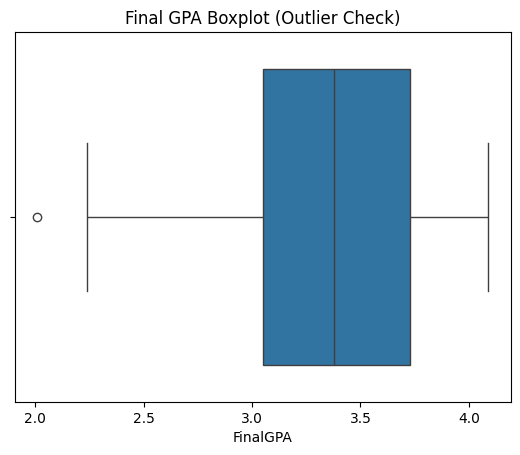

,FinalGPA,S1,S2,S3,S4,S5,S6,S7,S8,Zscore
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,3.359462,3.272769,3.520385,3.028462,3.252308,3.480231,3.409308,3.463692,3.489308,1.645606
std,0.455368,0.443821,0.391103,0.555899,0.543328,0.502577,0.575123,0.594937,0.513058,0.252893
min,2.010000,1.900000,2.210000,1.600000,1.390000,1.310000,1.140000,1.520000,1.350000,0.642600
25%,3.050000,2.952500,3.317500,2.632500,2.830000,3.172500,3.115000,3.117500,3.292500,1.507075
50%,3.380000,3.260000,3.550000,2.990000,3.275000,3.555000,3.580000,3.675000,3.580000,1.661650
75%,3.730000,3.650000,3.855000,3.457500,3.697500,3.887500,3.857500,3.930000,3.867500,1.824575
max,4.090000,4.120000,4.150000,4.090000,4.120000,4.180000,4.090000,4.140000,4.120000,2.239800


In [12]:
# print(df[["FinalGPA", "Zscore", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8","EnglishMarks"]].describe())

plt.figure()
sns.boxplot(x=df["FinalGPA"])
plt.title("Final GPA Boxplot (Outlier Check)")
plt.show()

df.describe()

In [15]:
def ClassCounts(FinalGPA):
    if FinalGPA <= 1.99:
        return "Fail"
    elif FinalGPA <= 2.99:
        return "Pass"
    elif FinalGPA <= 3.29:
        return "Second Lower"
    elif FinalGPA <= 3.69:
        return "Second Upper"
    else:
        return "High"

df["PerfGroup"] = df["FinalGPA"].apply(ClassCounts)
print(df["PerfGroup"].value_counts())


PerfGroup
High            39
Second Upper    34
Second Lower    30
Pass            27
Name: count, dtype: int64


Based on above counts:
Pass and fail are underperforming
Second Lower is Average
Second upper and first class is Performing

In [ ]:
def PerformanceGroupCounts(FinalGPA):
    if FinalGPA <= 2.00:
        return "Fail"
    elif FinalGPA <= 2.99:
        return "Pass"
    elif FinalGPA <= 3.29:
        return "Second Lower"
    elif FinalGPA <= 3.69:
        return "Second Upper"
    else:
        return "First class"

df["PerfGroup"] = df["FinalGPA"].apply(PerformanceGroupCounts)
print(df["PerfGroup"].value_counts())

PerfGroup
First class     40
Second Upper    33
Second Lower    29
Pass            24
Name: count, dtype: int64


In [ ]:
def PerformanceGroupCounts(FinalGPA):
    if FinalGPA <= 2.99:
        return "Underperforming"
    elif FinalGPA <= 3.29:
        return "Average"
    else:
        return "Performing"

df["PerfGroup"] = df["FinalGPA"].apply(PerformanceGroupCounts)
print(df["PerfGroup"].value_counts())

PerfGroup
Performing         73
Average            29
Underperforming    24
Name: count, dtype: int64


In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

for c in cat_cols[1:]:
    print("\n")
    print(df[c].value_counts(dropna=False).head(20))

Categorical columns: ['Index No.', 'Department', 'Gender', 'District', 'MediumAL', 'PerfGroup']


Department
BA     48
BPM    45
FSM    33
Name: count, dtype: int64


Gender
F    76
M    50
Name: count, dtype: int64


District
Colombo         30
Gampaha         12
Ratnapura        9
Matara           7
Kurunegala       7
Kandy            7
Kalutara         6
Kegalle          5
Badulla          5
Galle            5
Nuwara Eliya     4
Hambantota       4
Anuradhapura     3
Polonnaruwa      3
Puttalam         3
Ampara           3
Matale           3
Jaffna           2
Batticaloa       2
Monaragala       2
Name: count, dtype: int64


MediumAL
S    97
E    16
T    13
Name: count, dtype: int64


PerfGroup
Performing         73
Average            29
Underperforming    24
Name: count, dtype: int64


C:\Users\saw\AppData\Local\Temp\ipykernel_58344\3693009448.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [ ]:
count = (df[[f"S{i}" for i in range(1,9)]] == 0).sum()
print('Count of zero values in each semester column:')
print(count)

Count of zero values in each semester column:
S1    0
S2    0
S3    0
S4    0
S5    0
S6    0
S7    0
S8    0
dtype: int64


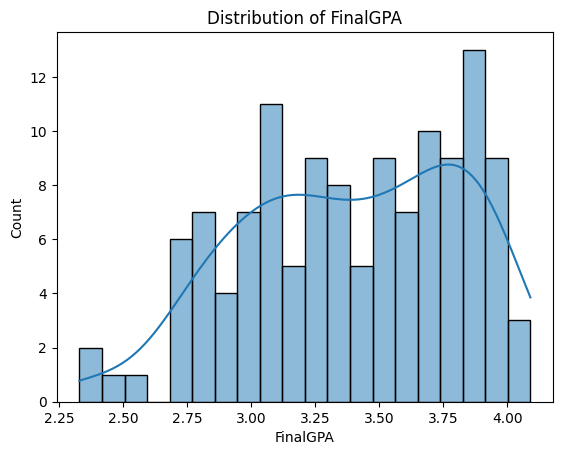

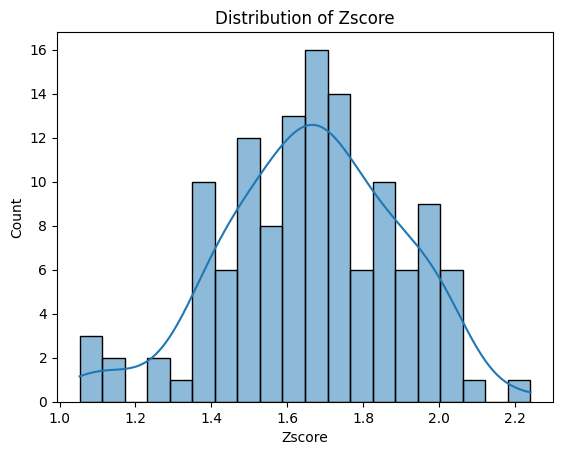

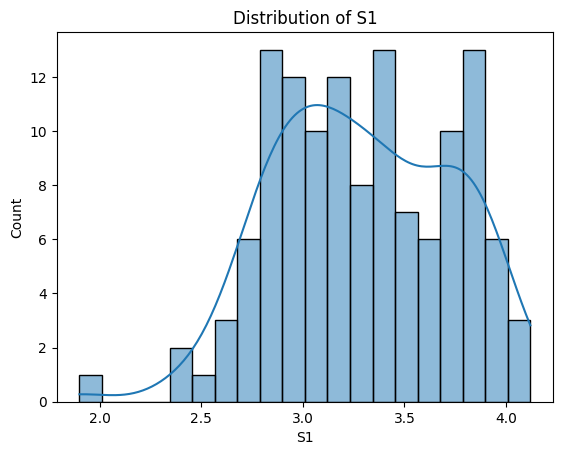

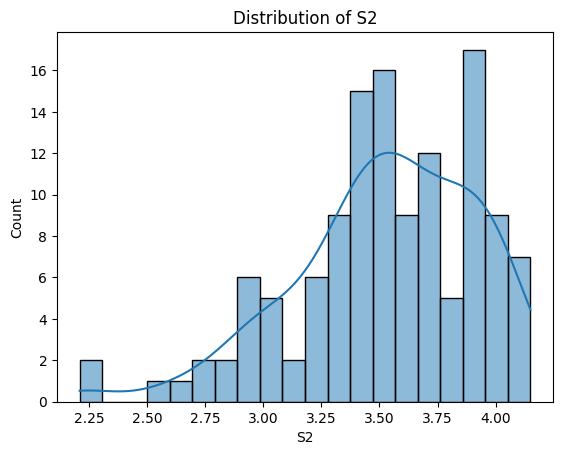

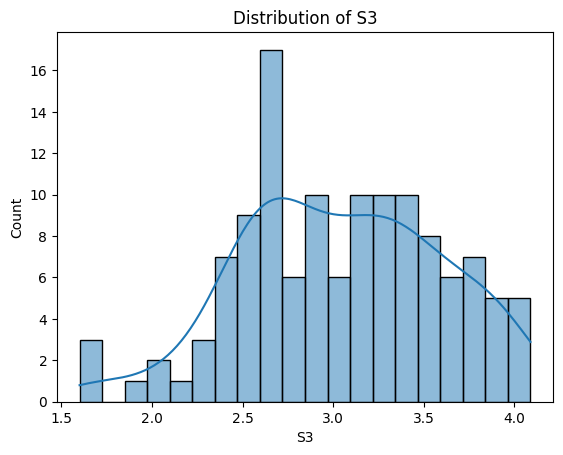

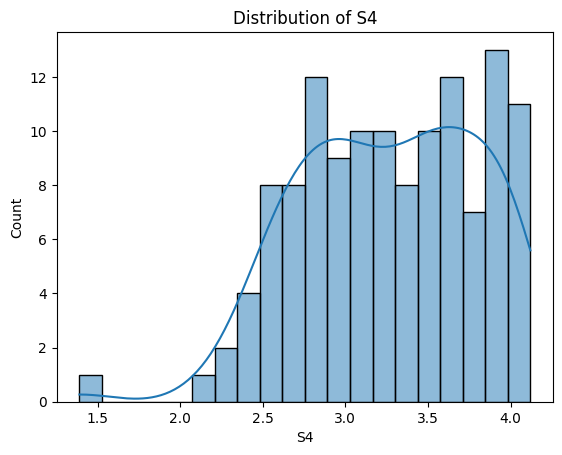

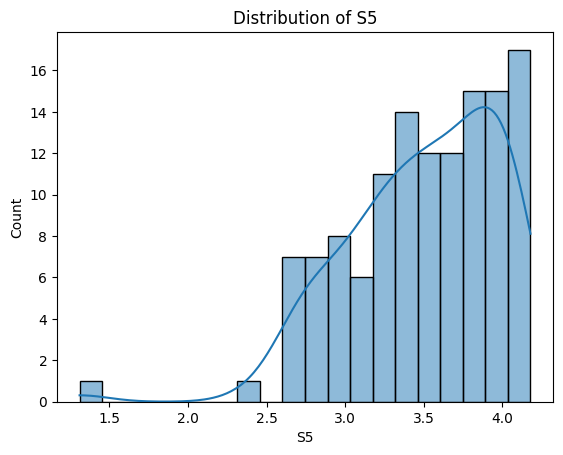

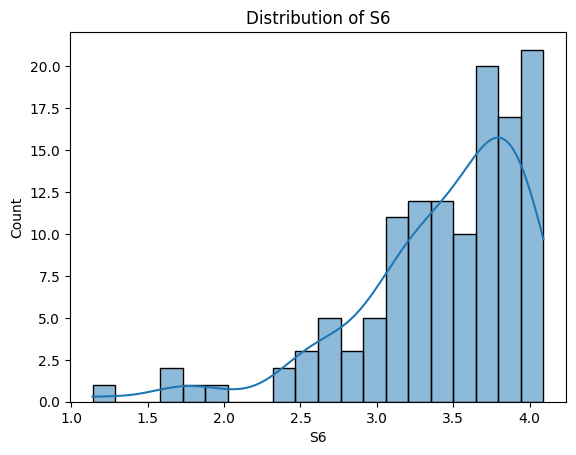

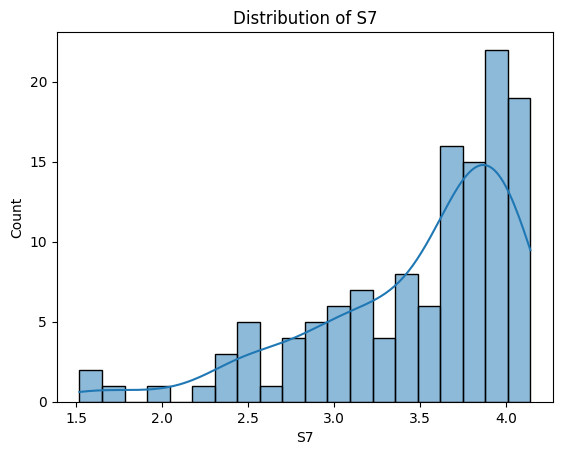

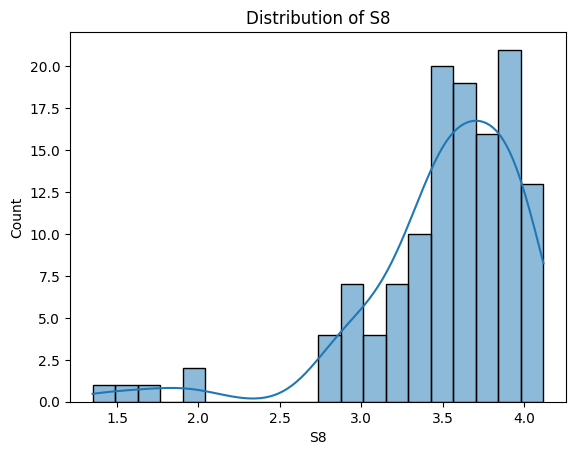

In [ ]:
num_pre_cols = ["FinalGPA", "Zscore","S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

for col in num_pre_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
for col in num_pre_cols:
    print(col, df[col].skew())

FinalGPA -0.3246541979021851
Zscore -0.29052400891505187
S1 -0.15799379964861138
S2 -0.8209799033511094
S3 -0.15020665154347482
S4 -0.3716050239951951
S5 -1.0005114755476994
S6 -1.4812749025596574
S7 -1.2674759935331157
S8 -1.9562664405617003


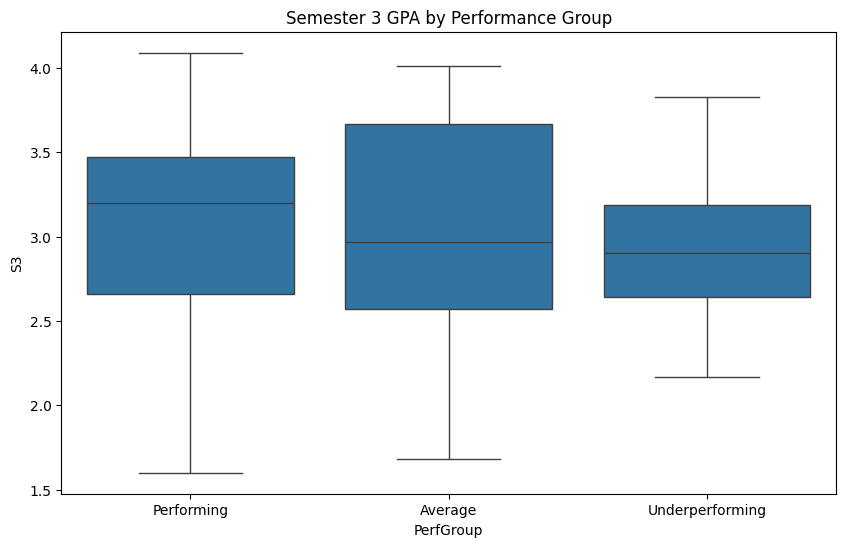

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S3"
)
plt.title("Semester 3 GPA by Performance Group")
plt.show()

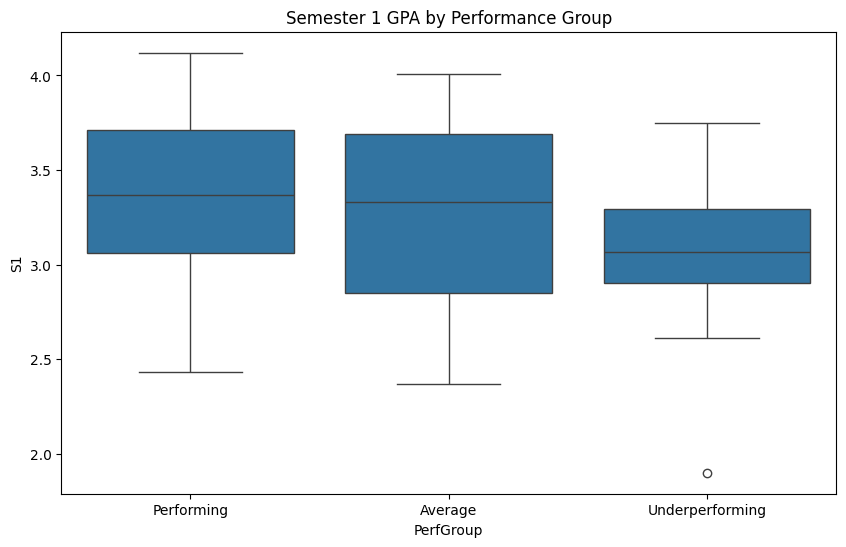

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S1"
)
plt.title("Semester 1 GPA by Performance Group")
plt.show()

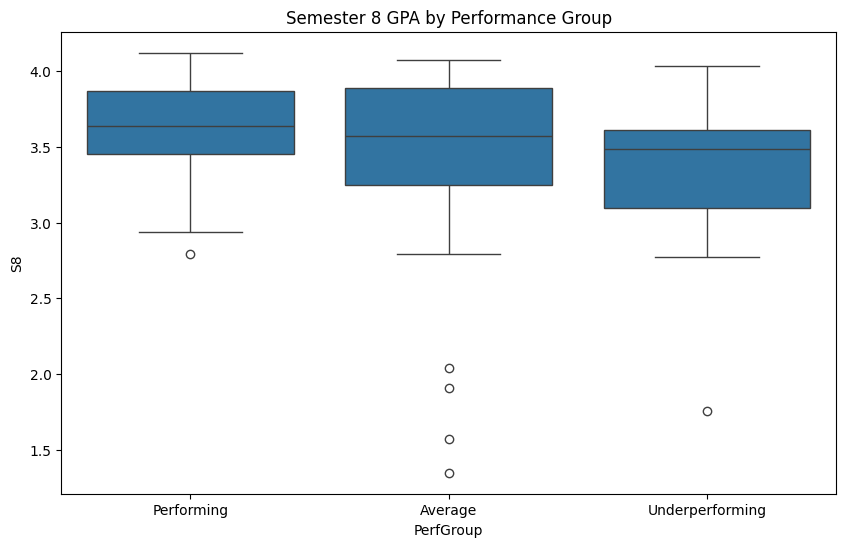

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S8"
)
plt.title("Semester 8 GPA by Performance Group")
plt.show()

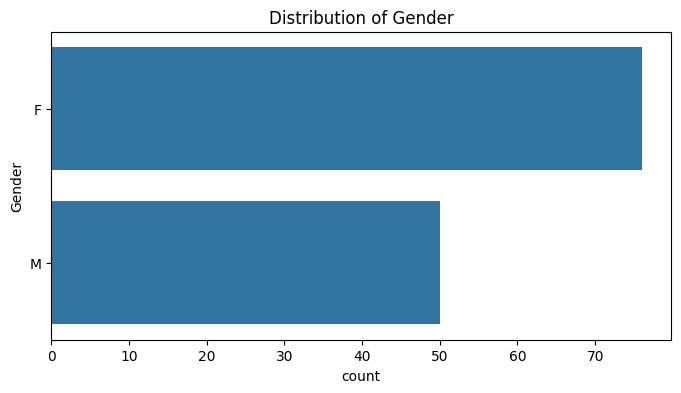

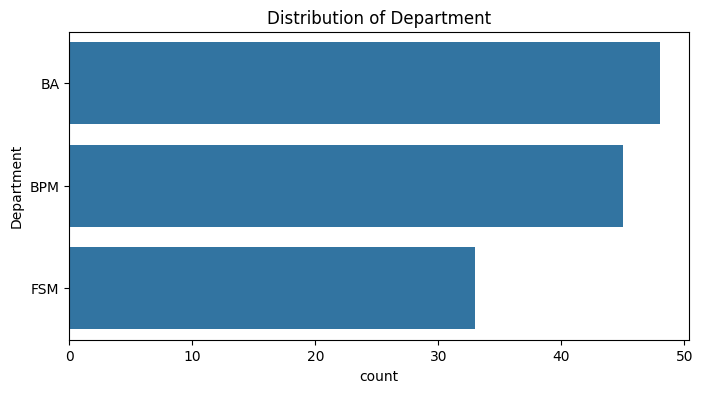

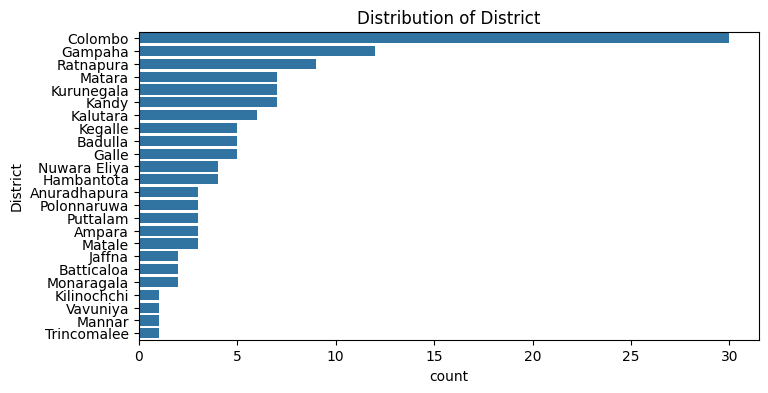

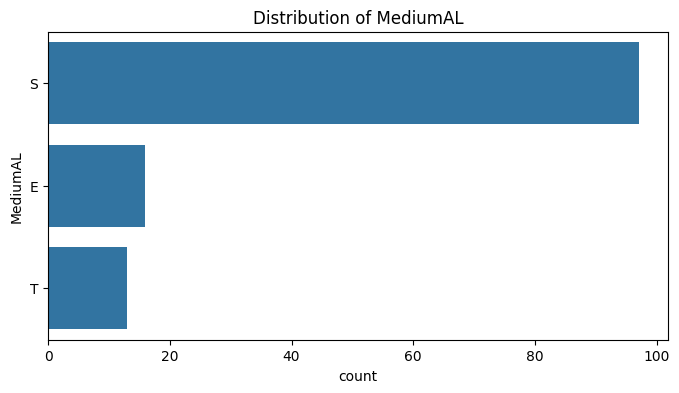

In [ ]:
cat_cols = ["Gender", "Department", "District", "MediumAL"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

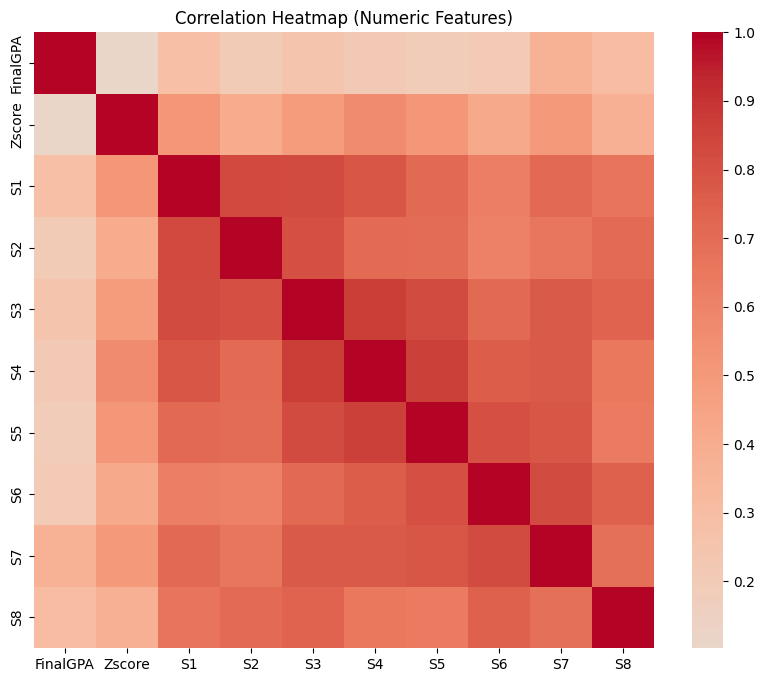

In [ ]:
num_cols_for_corr = ["FinalGPA", "Zscore", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[num_cols_for_corr].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()